# Objective 3 Visualization - Co-occurrence Network Layout

**Project:** Comparative Genomic and Network Analysis of Co-occurring Drug-Resistance Mutations Across African *M. tuberculosis* Lineages

**Purpose:** `objective3_network.py` computed the network's topology metrics
and community structure deterministically. This notebook is the
exploratory, iterative counterpart: it builds an actual force-directed
layout and renders the figures a reader needs to *see* the network, not
just read its statistics table.

**Why a notebook, not a script:** layout choices (which components to
show together, how to avoid 11 disconnected satellite components
scattering a spring layout across mostly-empty canvas, which nodes are
worth labelling) are visual judgement calls best made by looking at the
result and adjusting, not decided blind and locked into a non-interactive
script.

**Output:** four figures saved to `../results/objective3_visualization/`.

In [ ]:
OBJ3_DIR = "../results/objective3"
OUT_DIR = "../results/objective3_visualization"

import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs(OUT_DIR, exist_ok=True)

nodes = pd.read_csv(os.path.join(OBJ3_DIR, "network_nodes.csv"))
edges = pd.read_csv(os.path.join(OBJ3_DIR, "network_edges.csv"))
summary = pd.read_csv(os.path.join(OBJ3_DIR, "network_summary.csv")).iloc[0]
G = nx.read_graphml(os.path.join(OBJ3_DIR, "network.graphml"))

print(f"Loaded graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Expected from network_summary.csv: {int(summary['n_nodes_connected'])} nodes, {int(summary['n_edges'])} edges")
assert G.number_of_nodes() == int(summary["n_nodes_connected"])
assert G.number_of_edges() == int(summary["n_edges"])
print("Matches - graph loaded correctly.")

Loaded graph: 130 nodes, 441 edges
Expected from network_summary.csv: 130 nodes, 441 edges
Matches -- graph loaded correctly.


## 1. Separate the Giant Component from the Satellite Components

The network has 12 connected components: one giant component of 105 nodes
where all the interesting topological structure lives, and 11 tiny
satellite components of 2-3 nodes each. Laying all 12 out together with a
single force-directed layout would waste most of the canvas pushing the
disconnected satellites away from the giant component and from each
other, for no visual benefit -- they are shown separately instead.

In [2]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
giant_nodes = components[0]
satellite_components = components[1:]

G_giant = G.subgraph(giant_nodes).copy()
print(f"Giant component: {G_giant.number_of_nodes()} nodes, {G_giant.number_of_edges()} edges")
print(f"Satellite components: {len(satellite_components)}, sizes: {sorted([len(c) for c in satellite_components], reverse=True)}")

Giant component: 105 nodes, 424 edges
Satellite components: 11, sizes: [3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2]


## 2. Force-Directed Layout of the Giant Component

Using NetworkX's spring layout (Fruchterman-Reingold), weighted by each
edge's `-log10(padj_BH)` weight so more strongly-supported co-occurrence
pairs pull their nodes closer together. A fixed seed makes the layout
reproducible across re-runs.

In [3]:
pos_giant = nx.spring_layout(G_giant, weight="weight", seed=42, k=0.9, iterations=200)

# Node visual encoding: size by degree, color by Louvain community
degree_giant = dict(G_giant.degree())
community_giant = {n: G_giant.nodes[n]["louvain_community_id"] for n in G_giant.nodes()}
communities_present = sorted(set(community_giant.values()))
print(f"Communities within the giant component: {communities_present}")

cmap = plt.get_cmap("tab10")
community_color = {c: cmap(i % 10) for i, c in enumerate(communities_present)}
node_colors = [community_color[community_giant[n]] for n in G_giant.nodes()]
node_sizes = [80 + 25 * degree_giant[n] for n in G_giant.nodes()]

Communities within the giant component: [0, 1, 2, 3, 4, 5, 6, 8]


## 3. Main Figure: Giant Component, Coloured by Community

The top 15 nodes by degree are labelled directly; the rest are shown
unlabelled to keep the figure legible at this node count.

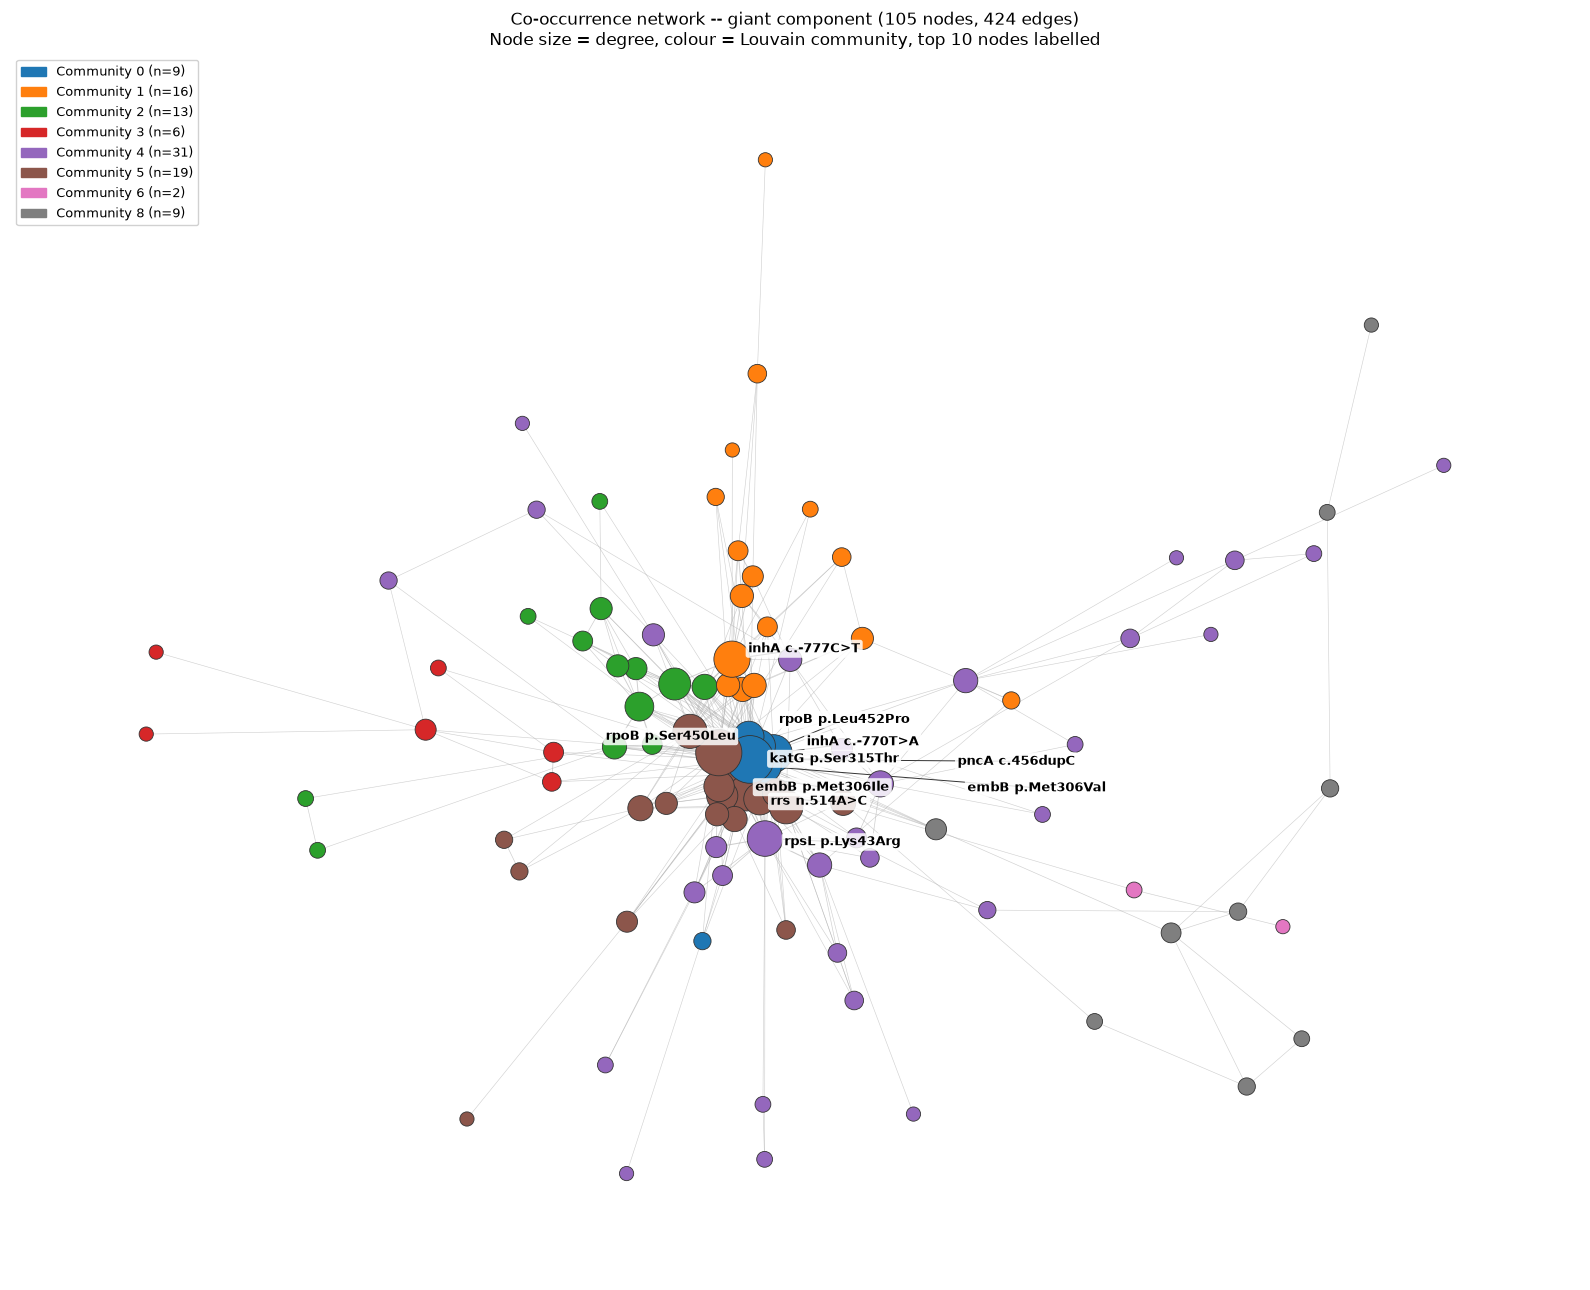

Saved: ../results/objective3_visualization/network_giant_component.png


In [ ]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(16, 13))

edge_weights = [G_giant[u][v]["weight"] for u, v in G_giant.edges()]
max_w = max(edge_weights)
edge_widths = [0.4 + 2.5 * (w / max_w) for w in edge_weights]

nx.draw_networkx_edges(G_giant, pos_giant, ax=ax, width=edge_widths, edge_color="#B0B0B0", alpha=0.6)
nx.draw_networkx_nodes(G_giant, pos_giant, ax=ax, node_size=node_sizes, node_color=node_colors, edgecolors="#333333", linewidths=0.6)

# Top 10 nodes by degree, labelled. adjustText only repositions the text to avoid
# overlap - it does NOT draw the connector line itself (its built-in arrow/
# FancyArrowPatch behaviour is matplotlib-version-sensitive and was confirmed to
# render a line straight through a label's text on at least one real environment).
# The connector from node to label is instead drawn manually below with a plain
# ax.plot() segment, which renders identically regardless of matplotlib version.
top10 = sorted(degree_giant.items(), key=lambda x: -x[1])[:10]
texts = []
node_xy_top10 = []
for mid, _ in top10:
    gene, change = mid.split("|", 1)
    x, y = pos_giant[mid]
    node_xy_top10.append((x, y))
    texts.append(ax.text(x, y, f"{gene} {change}", fontsize=9, fontweight="bold",
                          bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)))
adjust_text(texts, ax=ax)
for (x0, y0), t in zip(node_xy_top10, texts):
    tx, ty = t.get_position()
    ax.plot([x0, tx], [y0, ty], color="#333333", linewidth=0.7, zorder=1)

legend_handles = [mpatches.Patch(color=community_color[c], label=f"Community {c} (n={sum(1 for v in community_giant.values() if v==c)})")
                  for c in communities_present]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.9)
ax.set_title(f"Co-occurrence network - giant component ({G_giant.number_of_nodes()} nodes, {G_giant.number_of_edges()} edges)\n"
             f"Node size = degree, colour = Louvain community, top 10 nodes labelled", fontsize=12)
ax.axis("off")
plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "network_giant_component.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 4. Lineage-Confound Overlay

Objective 2's most important finding was that a large majority of
significant co-occurrence pairs are concentrated almost entirely within
one lineage - a signature of shared clonal ancestry rather than
necessarily a real pairwise interaction. This figure uses the same layout
as Figure 1 but colours edges by that diagnostic directly, so the scale
of the confound is visible at a glance rather than buried in a column of
a CSV.

Lineage-suspect edges (>=90% concentration) in the giant component: 282 / 424


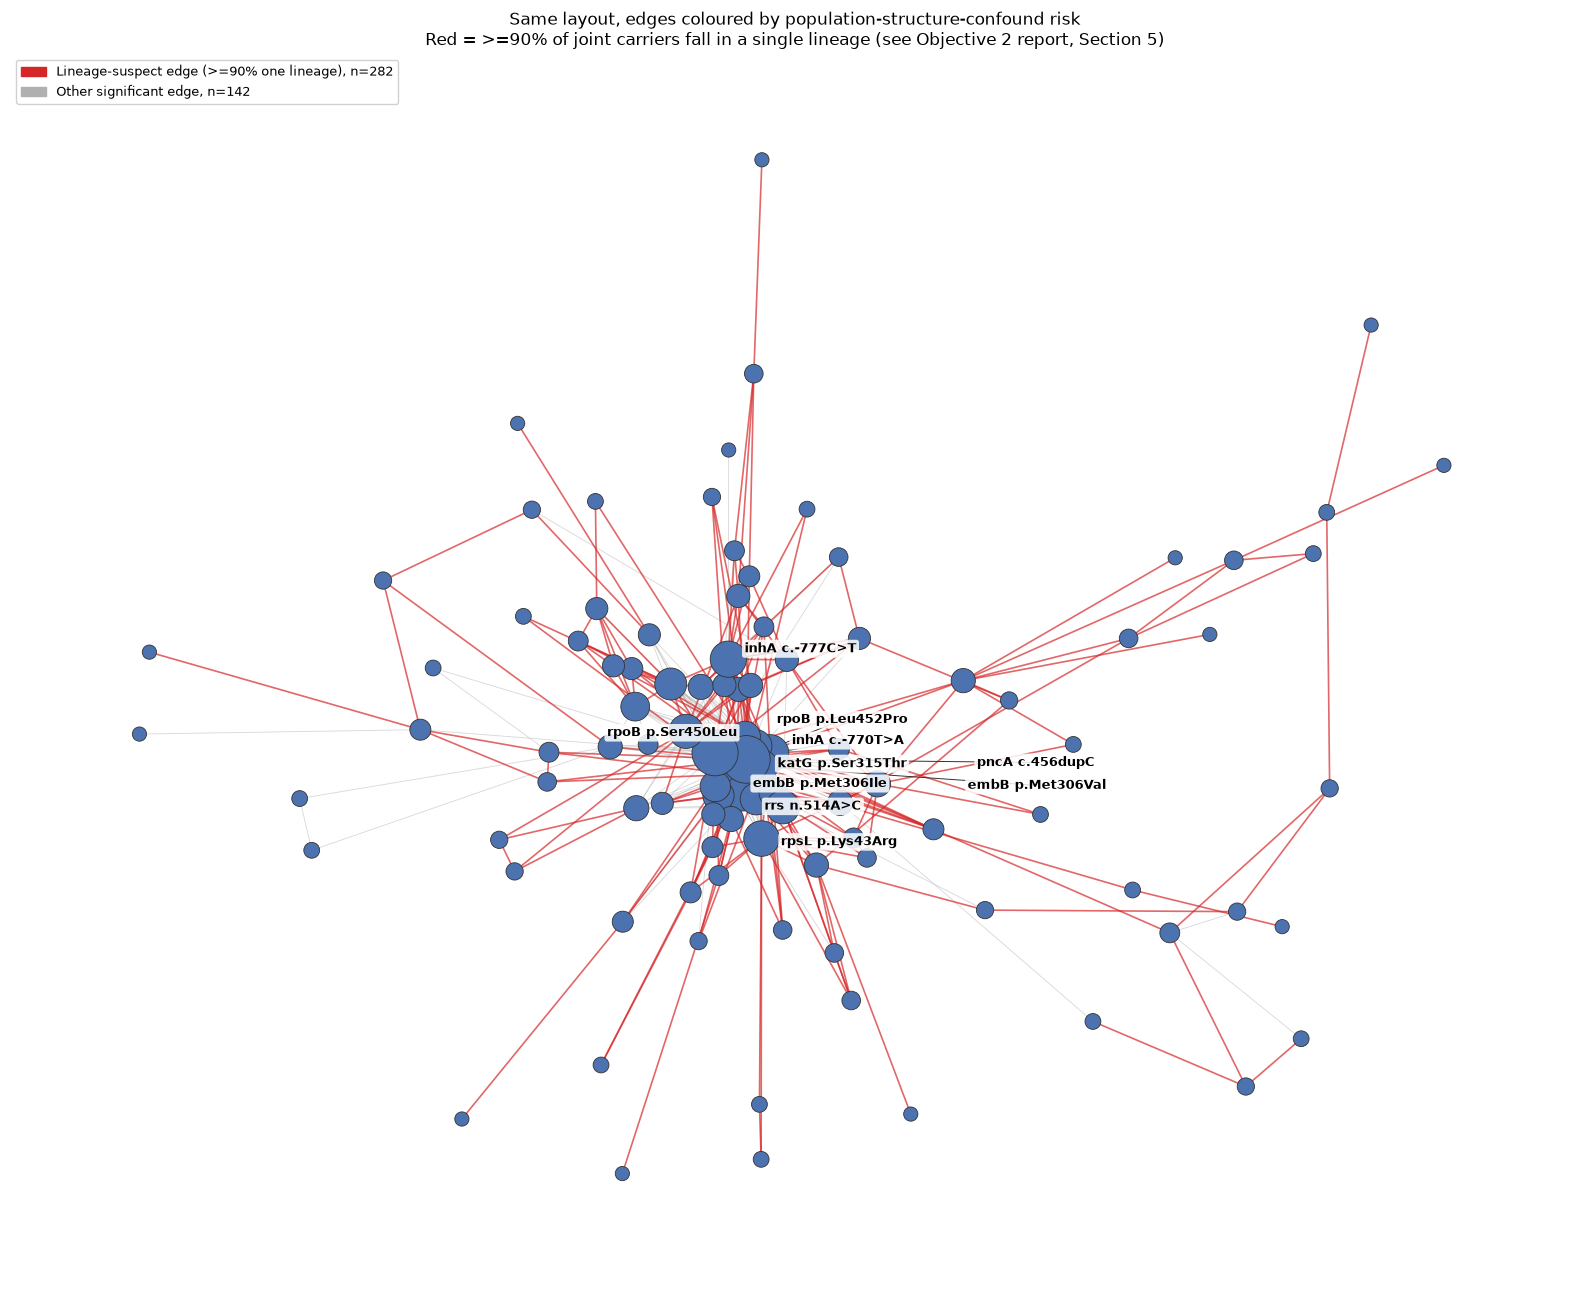

Saved: ../results/objective3_visualization/network_lineage_confound_overlay.png


In [ ]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(16, 13))

lineage_suspect_edges = []
other_edges = []
for u, v in G_giant.edges():
    pct = G_giant[u][v].get("pct_dominant_lineage")
    if pct is not None and float(pct) >= 90:
        lineage_suspect_edges.append((u, v))
    else:
        other_edges.append((u, v))

print(f"Lineage-suspect edges (>=90% concentration) in the giant component: {len(lineage_suspect_edges)} / {G_giant.number_of_edges()}")

nx.draw_networkx_edges(G_giant, pos_giant, ax=ax, edgelist=other_edges, width=0.6, edge_color="#B0B0B0", alpha=0.5)
nx.draw_networkx_edges(G_giant, pos_giant, ax=ax, edgelist=lineage_suspect_edges, width=1.2, edge_color="#D62728", alpha=0.7)
nx.draw_networkx_nodes(G_giant, pos_giant, ax=ax, node_size=node_sizes, node_color="#4C72B0",
                       edgecolors="#333333", linewidths=0.6)

# Same manual-connector approach as Figure 1 (see its cell for why) - avoids the
# matplotlib-version-sensitive arrow rendering from adjustText's own connectors.
texts = []
node_xy_top10 = []
for mid, _ in top10:
    gene, change = mid.split("|", 1)
    x, y = pos_giant[mid]
    node_xy_top10.append((x, y))
    texts.append(ax.text(x, y, f"{gene} {change}", fontsize=9, fontweight="bold",
                          bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)))
adjust_text(texts, ax=ax)
for (x0, y0), t in zip(node_xy_top10, texts):
    tx, ty = t.get_position()
    ax.plot([x0, tx], [y0, ty], color="#333333", linewidth=0.7, zorder=1)

legend_handles = [
    mpatches.Patch(color="#D62728", label=f"Lineage-suspect edge (>=90% one lineage), n={len(lineage_suspect_edges)}"),
    mpatches.Patch(color="#B0B0B0", label=f"Other significant edge, n={len(other_edges)}"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.9)
ax.set_title("Same layout, edges coloured by population-structure-confound risk\n"
             "Red = >=90% of joint carriers fall in a single lineage (see Objective 2 report, Section 5)", fontsize=12)
ax.axis("off")
plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "network_lineage_confound_overlay.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 5. The Satellite Components

The 11 disconnected components outside the giant component, each too
small to have any internal topology worth a force-directed layout (2-3
nodes each) -- shown here as a small grid instead, for completeness.

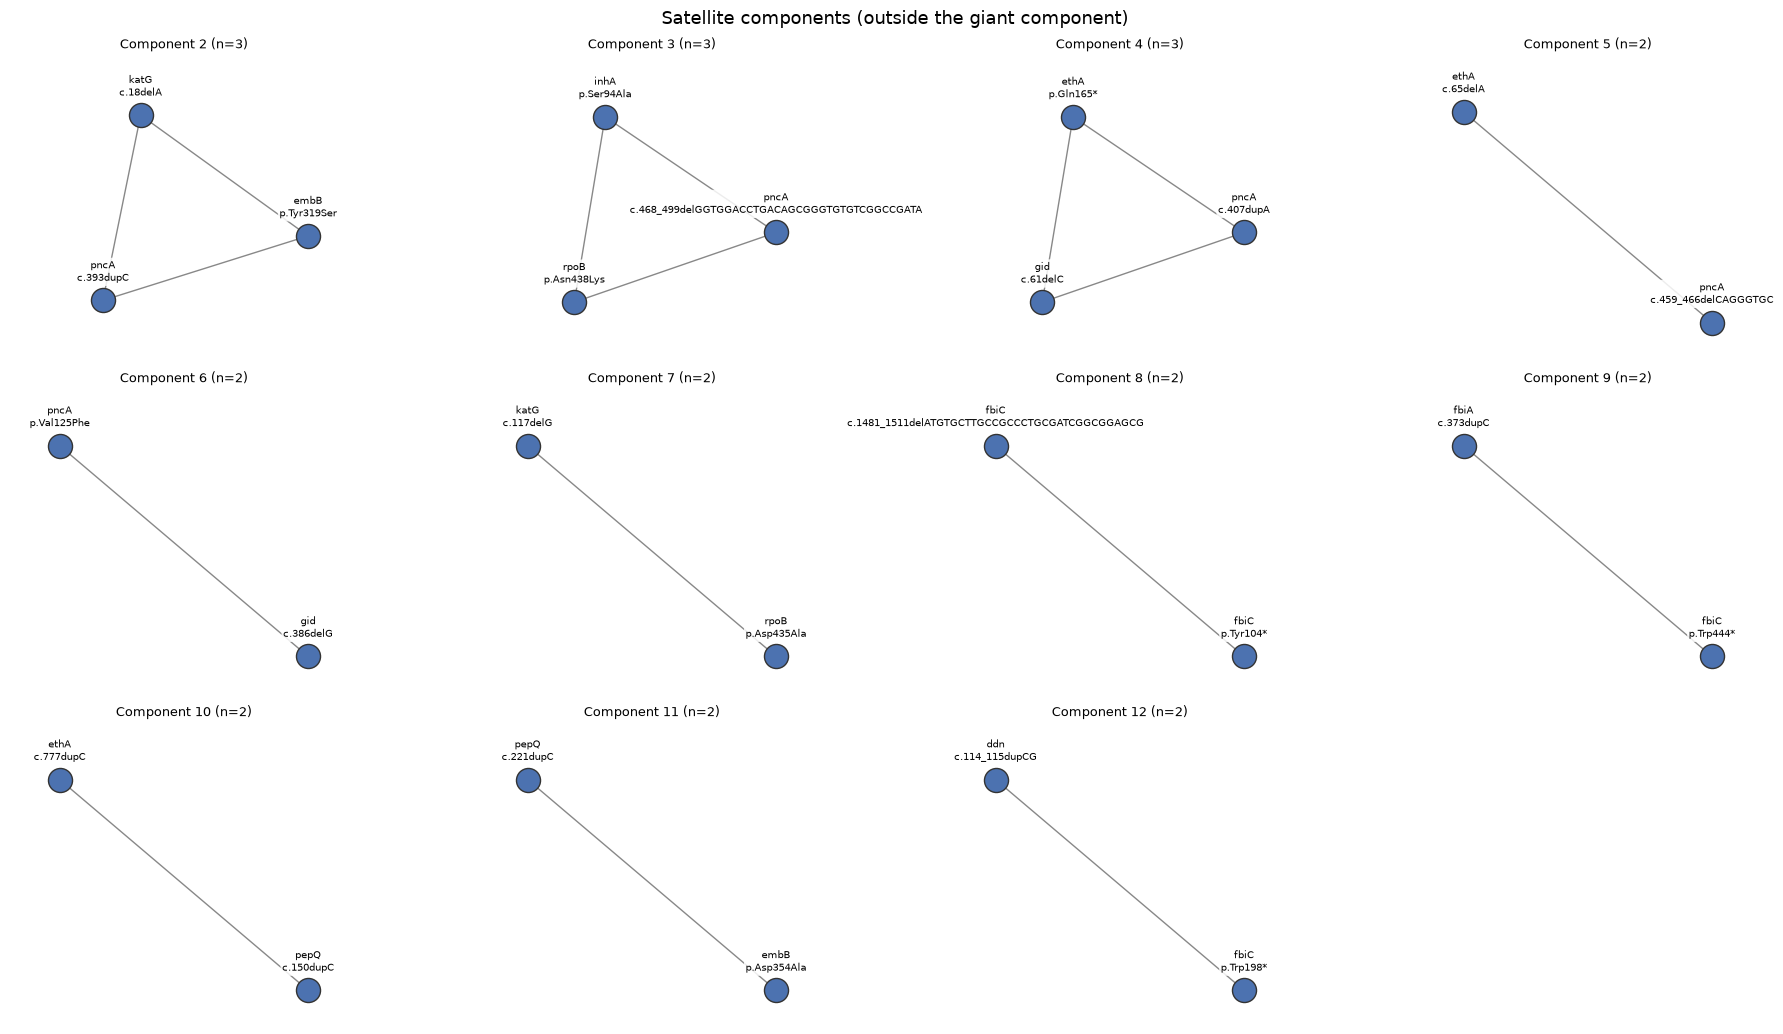

Saved: ../results/objective3_visualization/network_satellite_components.png


In [6]:
n_sat = len(satellite_components)
n_cols = 4
n_rows = int(np.ceil(n_sat / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, comp in enumerate(sorted(satellite_components, key=len, reverse=True)):
    ax = axes[i]
    subG = G.subgraph(comp)
    pos = nx.spring_layout(subG, seed=42, k=1.2)
    nx.draw_networkx_edges(subG, pos, ax=ax, width=1.0, edge_color="#888888")
    nx.draw_networkx_nodes(subG, pos, ax=ax, node_size=300, node_color="#4C72B0", edgecolors="#333333")
    for n in subG.nodes():
        x, y = pos[n]
        gene, change = n.split("|", 1)
        ax.text(x, y + 0.15, f"{gene}\n{change}", fontsize=7.5, ha="center", va="bottom",
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.3, 1.5)
    ax.set_title(f"Component {i+2} (n={len(comp)})", fontsize=9)
    ax.axis("off")

for j in range(n_sat, len(axes)):
    axes[j].axis("off")

plt.suptitle("Satellite components (outside the giant component)", fontsize=13)
plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "network_satellite_components.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 6. Supplementary: Degree and Centrality Distributions

Distributions across all 130 connected nodes (giant component + satellites
together), for reference alongside the node-level figures above.

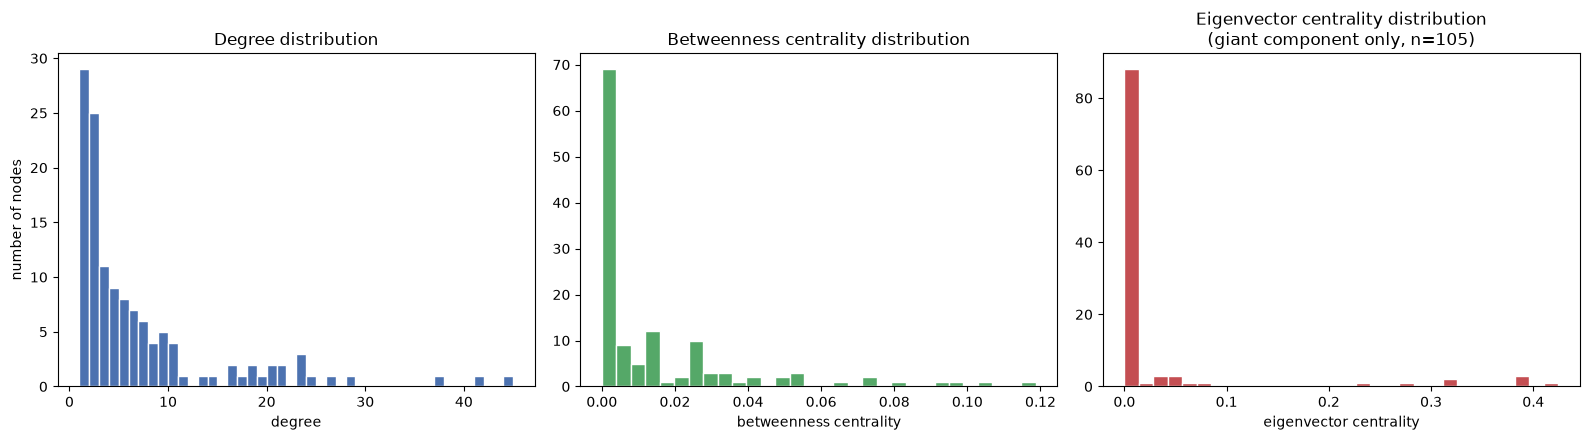

Saved: ../results/objective3_visualization/network_centrality_distributions.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(nodes["degree"], bins=range(1, nodes["degree"].max() + 2), color="#4C72B0", edgecolor="white")
axes[0].set_title("Degree distribution")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("number of nodes")

axes[1].hist(nodes["betweenness_centrality"], bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Betweenness centrality distribution")
axes[1].set_xlabel("betweenness centrality")

eigen_vals = nodes["eigenvector_centrality"].dropna()
axes[2].hist(eigen_vals, bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title(f"Eigenvector centrality distribution\n(giant component only, n={len(eigen_vals)})")
axes[2].set_xlabel("eigenvector centrality")

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "network_centrality_distributions.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## Summary

- The giant component (105 of 130 connected nodes) contains 7 internal
  Louvain communities and is the only part of the network with meaningful
  topological structure to visualise with a force-directed layout.
- 11 satellite components (2-3 nodes each) sit outside it, shown
  separately rather than let a spring layout scatter them across mostly
  empty canvas.
- The lineage-confound overlay makes Objective 2's central caveat visible
  directly on the network: a large share of edges, including many
  connecting the highest-degree nodes, are flagged as population-
  structure candidates rather than confirmed independent interactions.
- Four figures written to `results/objective3_visualization/`:
  `network_giant_component.png`, `network_lineage_confound_overlay.png`,
  `network_satellite_components.png`, `network_centrality_distributions.png`.